# SGC vs GCN Benchmark Harness

Runs both models on Cora / Citeseer / Pubmed across multiple seeds and produces a comparison table.

**Outputs per run:** test acc, val acc, best epoch, wall-clock training time, full loss/accuracy curves.

**Outputs aggregated:** mean ± std test accuracy and training time per (model, dataset).

## 1. Install dependencies

In [1]:
%%capture
!pip install torch torchvision torchaudio
!pip install torch_geometric

## 2. Imports and models

In [2]:
import time
from dataclasses import dataclass, field
from typing import List

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.datasets import Planetoid
from torch_geometric.nn import GCNConv
import torch_geometric.transforms as T
from torch_geometric.utils import add_self_loops, degree

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


In [3]:
class SGC(nn.Module):
    """Single linear layer applied to precomputed S^K X."""
    def __init__(self, nfeat, nclass):
        super().__init__()
        self.lin = nn.Linear(nfeat, nclass)
    def forward(self, x):
        return self.lin(x)

class GCN(nn.Module):
    """Standard 2-layer GCN, Kipf & Welling baseline."""
    def __init__(self, nfeat, nhid, nclass, dropout=0.5):
        super().__init__()
        self.conv1 = GCNConv(nfeat, nhid, cached=True)
        self.conv2 = GCNConv(nhid, nclass, cached=True)
        self.dropout = dropout
    def forward(self, x, edge_index):
        x = F.relu(self.conv1(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.conv2(x, edge_index)

## 3. SGC feature precompute and result container

In [4]:
def sgc_precompute(data, K=2):
    """Compute S^K X. Returns (features, precompute_time_seconds)."""
    t0 = time.perf_counter()
    edge_index, _ = add_self_loops(data.edge_index, num_nodes=data.num_nodes)
    row, col = edge_index
    deg = degree(col, data.num_nodes, dtype=data.x.dtype)
    deg_inv_sqrt = deg.pow(-0.5)
    deg_inv_sqrt[deg_inv_sqrt == float('inf')] = 0
    edge_weight = deg_inv_sqrt[row] * deg_inv_sqrt[col]
    adj = torch.sparse_coo_tensor(edge_index, edge_weight,
                                   (data.num_nodes, data.num_nodes)).to(data.x.device)
    x = data.x
    for _ in range(K):
        x = torch.spmm(adj, x)
    if x.is_cuda: torch.cuda.synchronize()
    return x, time.perf_counter() - t0

@dataclass
class RunResult:
    model: str
    dataset: str
    seed: int
    test_acc: float
    val_acc: float
    best_epoch: int
    train_time: float
    train_loss_curve: List[float] = field(default_factory=list)
    val_loss_curve: List[float] = field(default_factory=list)
    train_acc_curve: List[float] = field(default_factory=list)
    val_acc_curve: List[float] = field(default_factory=list)
    test_acc_curve: List[float] = field(default_factory=list)

def _accuracy(logits, y, mask):
    return (logits[mask].argmax(dim=1) == y[mask]).float().mean().item()

## 4. Train/eval routines (one per model)

In [5]:
def run_sgc(data, num_classes, seed, K=2, lr=0.2, weight_decay=8.5e-6, epochs=100):
    torch.manual_seed(seed); np.random.seed(seed)
    x_prop, t_pre = sgc_precompute(data, K=K)
    model = SGC(x_prop.shape[1], num_classes).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    tr_l, va_l, tr_a, va_a, te_a = [], [], [], [], []
    best_va, best_te, best_ep = 0.0, 0.0, 0
    t0 = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train(); opt.zero_grad()
        out = model(x_prop)
        loss = crit(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out = model(x_prop)
            tr_l.append(crit(out[data.train_mask], data.y[data.train_mask]).item())
            va_l.append(crit(out[data.val_mask], data.y[data.val_mask]).item())
            tr_a.append(_accuracy(out, data.y, data.train_mask))
            va_a.append(_accuracy(out, data.y, data.val_mask))
            te_a.append(_accuracy(out, data.y, data.test_mask))
        if va_a[-1] > best_va:
            best_va, best_te, best_ep = va_a[-1], te_a[-1], epoch
    if device.type == 'cuda': torch.cuda.synchronize()
    return RunResult('SGC', '', seed, best_te, best_va, best_ep,
                     t_pre + (time.perf_counter() - t0),
                     tr_l, va_l, tr_a, va_a, te_a)

def run_gcn(data, num_classes, seed, nhid=16, lr=0.01, weight_decay=5e-4,
            dropout=0.5, epochs=200, patience=10):
    torch.manual_seed(seed); np.random.seed(seed)
    model = GCN(data.num_features, nhid, num_classes, dropout=dropout).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    tr_l, va_l, tr_a, va_a, te_a = [], [], [], [], []
    best_va_loss = float('inf')
    best_va, best_te, best_ep = 0.0, 0.0, 0
    bad = 0
    t0 = time.perf_counter()
    for epoch in range(1, epochs + 1):
        model.train(); opt.zero_grad()
        out = model(data.x, data.edge_index)
        loss = crit(out[data.train_mask], data.y[data.train_mask])
        loss.backward(); opt.step()
        model.eval()
        with torch.no_grad():
            out = model(data.x, data.edge_index)
            tr_l.append(crit(out[data.train_mask], data.y[data.train_mask]).item())
            va_l.append(crit(out[data.val_mask], data.y[data.val_mask]).item())
            tr_a.append(_accuracy(out, data.y, data.train_mask))
            va_a.append(_accuracy(out, data.y, data.val_mask))
            te_a.append(_accuracy(out, data.y, data.test_mask))
        if va_a[-1] > best_va:
            best_va, best_te, best_ep = va_a[-1], te_a[-1], epoch
        if va_l[-1] < best_va_loss:
            best_va_loss = va_l[-1]; bad = 0
        else:
            bad += 1
            if bad >= patience: break
    if device.type == 'cuda': torch.cuda.synchronize()
    return RunResult('GCN', '', seed, best_te, best_va, best_ep,
                     time.perf_counter() - t0, tr_l, va_l, tr_a, va_a, te_a)

## 5. Top-level dispatcher

In [6]:
SGC_DATASET_OVERRIDES = {
    'Citeseer': {'epochs': 150},
}

def run_experiment(model_name, dataset_name, seed, **hparams):
    dataset = Planetoid(root=f'./data/{dataset_name}', name=dataset_name,
                        transform=T.NormalizeFeatures())
    data = dataset[0].to(device)
    if model_name.lower() == 'sgc':

        overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
        merged = {**overrides, **hparams}
        res = run_sgc(data, dataset.num_classes, seed, **merged)
    elif model_name.lower() == 'gcn':
        res = run_gcn(data, dataset.num_classes, seed, **hparams)
    else:
        raise ValueError(model_name)
    res.dataset = dataset_name
    return res

## 6. Tune SGC weight decay (per dataset)

Grid-search `weight_decay` over a small log-spaced grid using **validation** accuracy. We use a few seeds per `wd` to reduce noise from random init. The best `wd` per dataset is then used for final test evaluation in the next cell.

In [7]:
WD_GRID = [1e-7, 1e-6, 5e-6, 1e-5, 5e-5, 1e-4, 5e-4]
TUNE_SEEDS = 3
DATASETS = ['Cora', 'Citeseer', 'Pubmed']

def tune_sgc_wd(dataset_name, wd_grid=WD_GRID, tune_seeds=TUNE_SEEDS):
    dataset = Planetoid(root=f'./data/{dataset_name}', name=dataset_name,
                        transform=T.NormalizeFeatures())
    data = dataset[0].to(device)
    grid = {}
    print(f'\nTuning SGC on {dataset_name} (grid={wd_grid}, seeds={tune_seeds}):')
    overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
    for wd in wd_grid:
        vas = [run_sgc(data, dataset.num_classes, s,
                       weight_decay=wd, **overrides).val_acc
               for s in range(tune_seeds)]
        grid[wd] = (np.mean(vas), np.std(vas))
        print(f'  wd={wd:.0e}  val={grid[wd][0]*100:.2f} ± {grid[wd][1]*100:.2f}')
    best = max(wd_grid, key=lambda w: grid[w][0])
    print(f'  → best wd = {best:.0e}')
    return best, grid

SGC_WD = {}
TUNE_GRIDS = {}
for ds in DATASETS:
    SGC_WD[ds], TUNE_GRIDS[ds] = tune_sgc_wd(ds)

print('\n=== Selected weight decays ===')
for ds, wd in SGC_WD.items():
    print(f'  {ds:<10} wd = {wd:.0e}')

Processing...
Done!



Tuning SGC on Cora (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=77.47 ± 0.09
  wd=1e-06  val=77.80 ± 0.00
  wd=5e-06  val=79.20 ± 0.00
  wd=1e-05  val=79.67 ± 0.09
  wd=5e-05  val=79.53 ± 0.09
  wd=1e-04  val=79.53 ± 0.19
  wd=5e-04  val=78.93 ± 0.66
  → best wd = 1e-05


Processing...
Done!



Tuning SGC on Citeseer (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=69.40 ± 0.28
  wd=1e-06  val=69.80 ± 0.16
  wd=5e-06  val=70.13 ± 0.09
  wd=1e-05  val=71.07 ± 0.09
  wd=5e-05  val=73.60 ± 0.00
  wd=1e-04  val=73.87 ± 0.09
  wd=5e-04  val=73.53 ± 0.41
  → best wd = 1e-04


Processing...
Done!



Tuning SGC on Pubmed (grid=[1e-07, 1e-06, 5e-06, 1e-05, 5e-05, 0.0001, 0.0005], seeds=3):
  wd=1e-07  val=77.40 ± 0.00
  wd=1e-06  val=77.33 ± 0.09
  wd=5e-06  val=78.00 ± 0.00
  wd=1e-05  val=79.20 ± 0.00
  wd=5e-05  val=81.60 ± 0.00
  wd=1e-04  val=82.00 ± 0.00
  wd=5e-04  val=79.40 ± 0.28
  → best wd = 1e-04

=== Selected weight decays ===
  Cora       wd = 1e-05
  Citeseer   wd = 1e-04
  Pubmed     wd = 1e-04


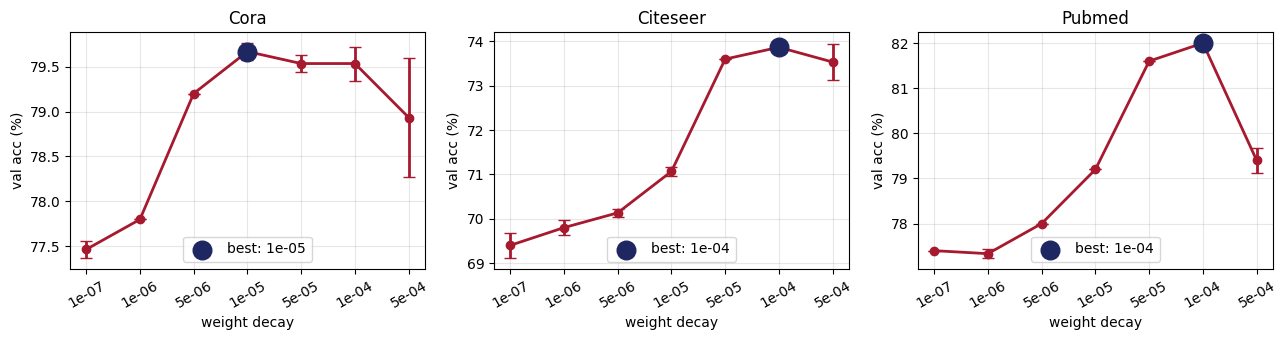

In [8]:
# Visualize the wd grid — useful for the writeup, shows tuning was actually informative
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, len(DATASETS), figsize=(13, 3.5), sharey=False)
for ax, ds in zip(axes, DATASETS):
    grid = TUNE_GRIDS[ds]
    wds = sorted(grid.keys())
    means = [grid[w][0] * 100 for w in wds]
    stds = [grid[w][1] * 100 for w in wds]
    ax.errorbar(range(len(wds)), means, yerr=stds, marker='o', capsize=4,
                color='#A6192E', linewidth=2)
    best = SGC_WD[ds]
    bi = wds.index(best)
    ax.scatter([bi], [means[bi]], s=180, color='#1E2761', zorder=5,
               label=f'best: {best:.0e}')
    ax.set_xticks(range(len(wds)))
    ax.set_xticklabels([f'{w:.0e}' for w in wds], rotation=30)
    ax.set_xlabel('weight decay')
    ax.set_ylabel('val acc (%)')
    ax.set_title(ds)
    ax.legend(loc='lower center')
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Run the full benchmark (with tuned SGC weight decay)

In [ ]:
MODELS = ['sgc', 'gcn']
SEEDS = list(range(10))

results = []
for model_name in MODELS:
    for ds in DATASETS:
        for seed in SEEDS:
            hparams = {}
            if model_name == 'sgc' and ds in SGC_WD:
                hparams['weight_decay'] = SGC_WD[ds]
            r = run_experiment(model_name, ds, seed, **hparams)
            results.append(r)
            print(f'[{model_name:>3}/{ds:<8} seed={seed}] '
                  f'test={r.test_acc*100:.2f}% '
                  f'val={r.val_acc*100:.2f}% '
                  f'epoch={r.best_epoch:3d} '
                  f'time={r.train_time:.3f}s')

[sgc/Cora     seed=0] test=80.20% val=79.60% epoch= 36 time=0.309s
[sgc/Cora     seed=1] test=80.00% val=79.60% epoch= 40 time=0.298s
[sgc/Cora     seed=2] test=79.90% val=79.80% epoch= 40 time=0.295s
[sgc/Cora     seed=3] test=79.60% val=79.40% epoch= 43 time=0.306s
[sgc/Cora     seed=4] test=79.80% val=79.60% epoch= 40 time=0.294s
[sgc/Cora     seed=5] test=79.80% val=79.80% epoch= 44 time=0.290s
[sgc/Cora     seed=6] test=79.70% val=79.60% epoch= 43 time=0.304s
[sgc/Cora     seed=7] test=79.90% val=79.60% epoch= 40 time=0.294s
[sgc/Cora     seed=8] test=80.30% val=79.80% epoch= 38 time=0.294s
[sgc/Cora     seed=9] test=80.10% val=79.80% epoch= 40 time=0.290s
[sgc/Citeseer seed=0] test=71.70% val=74.00% epoch= 45 time=0.525s
[sgc/Citeseer seed=1] test=72.00% val=73.80% epoch= 96 time=0.521s
[sgc/Citeseer seed=2] test=72.00% val=73.80% epoch= 99 time=0.506s
[sgc/Citeseer seed=3] test=72.00% val=73.80% epoch= 95 time=0.519s
[sgc/Citeseer seed=4] test=72.00% val=73.80% epoch= 96 time=0.

## 8. Independent Exploration

In [11]:
# Independent Exploration. 'Actor' dataset, a heterophilic graph where nodes are actors and
# edges connect actors who appeared on the same Wikipedia page. The classification task is
# to predict which of 5 categories each actor belongs to based on keywords from their Wikipedia
# page. Code is intended to test whether SGC's simplification holds outside the homophilic
# Planetoid datasets. Both models plateau near ~29% (5-class chance = 20%), showing the
# bottleneck is neighborhood averaging over heterophilic edges, not the presence or absence of
# nonlinearity between propagation steps.

import numpy as np
import pandas as pd
import torch
import torch_geometric.transforms as T
from torch_geometric.data import Data

from google.colab import drive
drive.mount('/content/drive')

# File paths. Replace with yours when running.
NODE_FILE   = "/content/drive/MyDrive/actor_nodes.txt"
EDGE_FILE   = "/content/drive/MyDrive/actor_edges.txt"
FEATURE_DIM = 931


def load_actor_pyg() -> Data:
    """Load Actor dataset from local txt files with the Geom-GCN 60/20/20 split."""
    node_df = pd.read_csv(NODE_FILE, sep="\t")
    feat_col = [c for c in node_df.columns if c.startswith("feature")][0]
    node_df = node_df.rename(columns={feat_col: "feature"})
    node_df = node_df.sort_values("node_id").reset_index(drop=True)
    N = len(node_df)

    x = torch.zeros(N, FEATURE_DIM, dtype=torch.float32)
    for i, row in enumerate(node_df["feature"]):
        for idx in (int(v) for v in str(row).split(",") if v.strip()):
            if idx < FEATURE_DIM:
                x[i, idx] = 1.0

    y = torch.tensor(node_df["label"].to_numpy(dtype=np.int64))

    edge_df = pd.read_csv(EDGE_FILE, sep="\t", header=0)
    edge_df.columns = ["src", "dst"]
    all_ids = sorted(node_df["node_id"].tolist())
    id_map  = {nid: i for i, nid in enumerate(all_ids)}
    src = torch.tensor([id_map[s] for s in edge_df["src"]], dtype=torch.long)
    dst = torch.tensor([id_map[d] for d in edge_df["dst"]], dtype=torch.long)
    edge_index = torch.unique(
        torch.stack([torch.cat([src, dst]), torch.cat([dst, src])], dim=0), dim=1
    )

    num_classes = int(y.max().item()) + 1

    # Geom-GCN protocol: 60/20/20 random split (Pei et al. 2020)
    # Standard heterophily benchmarking protocol; documented GCN accuracy ~26-30%
    rng        = np.random.default_rng(42)
    perm       = rng.permutation(N)
    n_tr       = int(N * 0.6)
    n_val      = int(N * 0.2)
    train_idx  = perm[:n_tr]
    val_idx    = perm[n_tr : n_tr + n_val]
    test_idx   = perm[n_tr + n_val :]

    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)
    train_mask[train_idx] = True
    val_mask[val_idx]     = True
    test_mask[test_idx]   = True

    data = Data(x=x, y=y, edge_index=edge_index,
                train_mask=train_mask, val_mask=val_mask, test_mask=test_mask)
    data.num_classes = num_classes
    data = T.NormalizeFeatures()(data)
    return data

# Patch tune_sgc_wd so it doesn't try to load Actor via Planetoid (no longer hosted on this repo)
_orig_tune_sgc_wd = tune_sgc_wd

def tune_sgc_wd(dataset_name, wd_grid=WD_GRID, tune_seeds=TUNE_SEEDS):
    if dataset_name == 'Actor':
        data = load_actor_pyg().to(device)
        grid = {}
        print(f'\nTuning SGC on {dataset_name} (grid={wd_grid}, seeds={tune_seeds}):')
        overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
        for wd in wd_grid:
            vas = [run_sgc(data, data.num_classes, s,
                           weight_decay=wd, **overrides).val_acc
                   for s in range(tune_seeds)]
            grid[wd] = (np.mean(vas), np.std(vas))
            print(f'  wd={wd:.0e}  val={grid[wd][0]*100:.2f} ± {grid[wd][1]*100:.2f}')
        best = max(wd_grid, key=lambda w: grid[w][0])
        print(f'  → best wd = {best:.0e}')
        return best, grid
    return _orig_tune_sgc_wd(dataset_name, wd_grid=wd_grid, tune_seeds=tune_seeds)


# Patch run_experiment so the benchmark loop handles Actor
_orig_run_experiment = run_experiment

def run_experiment(model_name, dataset_name, seed, **hparams):
    if dataset_name == 'Actor':
        data = load_actor_pyg().to(device)
        if model_name.lower() == 'sgc':
            overrides = SGC_DATASET_OVERRIDES.get('Actor', {})
            res = run_sgc(data, data.num_classes, seed, **{**overrides, **hparams})
        elif model_name.lower() == 'gcn':
            res = run_gcn(data, data.num_classes, seed, **hparams)
        else:
            raise ValueError(model_name)
        res.dataset = 'Actor'
        return res
    return _orig_run_experiment(model_name, dataset_name, seed, **hparams)


if 'Actor' not in DATASETS:
    DATASETS.append('Actor')
SGC_WD['Actor'], TUNE_GRIDS['Actor'] = tune_sgc_wd('Actor')


# Benchmark for Actor dataset
for model_name in MODELS:
    for seed in SEEDS:
        hparams = {'weight_decay': SGC_WD['Actor']} if model_name == 'sgc' else {}
        r = run_experiment(model_name, 'Actor', seed, **hparams)
        results.append(r)
        print(f'[{model_name:>3}/Actor    seed={seed}] '
              f'test={r.test_acc*100:.2f}% '
              f'val={r.val_acc*100:.2f}% '
              f'epoch={r.best_epoch:3d} '
              f'time={r.train_time:.3f}s')

KeyboardInterrupt: 

In [12]:
from google.colab import drive
drive.mount('/content/drive')

KeyboardInterrupt: 

In [21]:
## Experimenting with various levels of Homophily: Chameleon, Squirrel, Texas, Cornell

In [13]:
from torch_geometric.datasets import WebKB, WikipediaNetwork

def load_hetero_dataset(name):
    if name == 'Cornell':
        d = WebKB(root='./data/Cornell', name='Cornell', transform=T.NormalizeFeatures())[0]
    elif name == 'Texas':
        d = WebKB(root='./data/Texas', name='Texas', transform=T.NormalizeFeatures())[0]
    elif name == 'Chameleon':
        d = WikipediaNetwork(root='./data/Chameleon', name='chameleon', transform=T.NormalizeFeatures())[0]
    elif name == 'Squirrel':
        d = WikipediaNetwork(root='./data/Squirrel', name='squirrel', transform=T.NormalizeFeatures())[0]
    return d

def compute_homophily(data):
    row, col = data.edge_index
    same_class = (data.y[row] == data.y[col]).float()
    return same_class.mean().item()

# datasets to add
HETERO_DATASETS = ['Cornell', 'Texas', 'Chameleon', 'Squirrel']

In [14]:
def add_random_split(data, seed=42):
    N = data.num_nodes
    rng = np.random.default_rng(seed)
    perm = rng.permutation(N)
    n_tr  = int(N * 0.6)
    n_val = int(N * 0.2)
    train_mask = torch.zeros(N, dtype=torch.bool)
    val_mask   = torch.zeros(N, dtype=torch.bool)
    test_mask  = torch.zeros(N, dtype=torch.bool)
    train_mask[perm[:n_tr]]            = True
    val_mask[perm[n_tr:n_tr + n_val]]  = True
    test_mask[perm[n_tr + n_val:]]     = True
    data.train_mask = train_mask
    data.val_mask   = val_mask
    data.test_mask  = test_mask
    return data

# patch run_experiment to handle new datasets
_orig_run_experiment2 = run_experiment

def run_experiment(model_name, dataset_name, seed, **hparams):
    if dataset_name in HETERO_DATASETS:
        data = load_hetero_dataset(dataset_name)
        data = add_random_split(data, seed=seed)
        data = data.to(device)
        num_classes = int(data.y.max().item()) + 1
        if model_name.lower() == 'sgc':
            overrides = SGC_DATASET_OVERRIDES.get(dataset_name, {})
            res = run_sgc(data, num_classes, seed, **{**overrides, **hparams})
        else:
            res = run_gcn(data, num_classes, seed, **hparams)
        res.dataset = dataset_name
        return res
    return _orig_run_experiment2(model_name, dataset_name, seed, **hparams)

# tune weight decay for new datasets
for ds in HETERO_DATASETS:
    data = load_hetero_dataset(ds)
    data = add_random_split(data)
    data = data.to(device)
    num_classes = int(data.y.max().item()) + 1
    grid = {}
    for wd in WD_GRID:
        vas = [run_sgc(data, num_classes, s, weight_decay=wd).val_acc
               for s in range(TUNE_SEEDS)]
        grid[wd] = (np.mean(vas), np.std(vas))
    best = max(WD_GRID, key=lambda w: grid[w][0])
    SGC_WD[ds] = best
    print(f'{ds}: best wd = {best:.0e}')

# run full benchmark on heterophilic datasets
for model_name in MODELS:
    for ds in HETERO_DATASETS:
        for seed in SEEDS:
            hparams = {'weight_decay': SGC_WD[ds]} if model_name == 'sgc' else {}
            r = run_experiment(model_name, ds, seed, **hparams)
            results.append(r)
            print(f'[{model_name:>3}/{ds:<10} seed={seed}] '
                  f'test={r.test_acc*100:.2f}%  time={r.train_time:.3f}s')

Processing...
Done!


Cornell: best wd = 1e-07


Processing...
Done!


Texas: best wd = 5e-05


Processing...
Done!


Chameleon: best wd = 1e-06


Processing...
Done!


Squirrel: best wd = 1e-07
[sgc/Cornell    seed=0] test=34.21%  time=0.338s
[sgc/Cornell    seed=1] test=60.53%  time=0.356s
[sgc/Cornell    seed=2] test=44.74%  time=0.284s
[sgc/Cornell    seed=3] test=63.16%  time=0.282s
[sgc/Cornell    seed=4] test=52.63%  time=0.249s
[sgc/Cornell    seed=5] test=60.53%  time=0.262s
[sgc/Cornell    seed=6] test=55.26%  time=0.278s
[sgc/Cornell    seed=7] test=47.37%  time=0.265s
[sgc/Cornell    seed=8] test=57.89%  time=0.289s
[sgc/Cornell    seed=9] test=42.11%  time=0.281s
[sgc/Texas      seed=0] test=50.00%  time=0.260s
[sgc/Texas      seed=1] test=57.89%  time=0.265s
[sgc/Texas      seed=2] test=50.00%  time=0.264s
[sgc/Texas      seed=3] test=52.63%  time=0.272s
[sgc/Texas      seed=4] test=63.16%  time=0.255s
[sgc/Texas      seed=5] test=63.16%  time=0.254s
[sgc/Texas      seed=6] test=60.53%  time=0.254s
[sgc/Texas      seed=7] test=63.16%  time=0.266s
[sgc/Texas      seed=8] test=57.89%  time=0.257s
[sgc/Texas      seed=9] test=71.05%  time=0

Cora: homophily = 0.810
Citeseer: homophily = 0.736
Pubmed: homophily = 0.802
Cornell: homophily = 0.131
Texas: homophily = 0.108
Chameleon: homophily = 0.235
Squirrel: homophily = 0.224


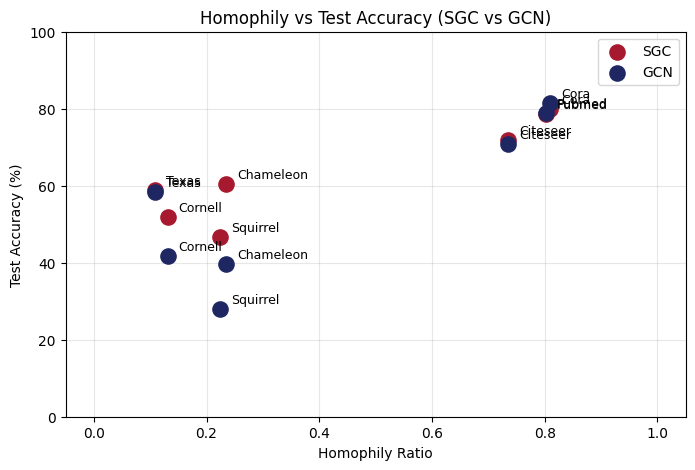

In [20]:
colors = {'SGC': '#A6192E', 'GCN': '#1E2761'}
ALL_DATASETS = ['Cora', 'Citeseer', 'Pubmed'] + HETERO_DATASETS

homophily_vals = {}
for ds in ALL_DATASETS:
    if ds in ['Cora', 'Citeseer', 'Pubmed']:
        data = Planetoid(root=f'./data/{ds}', name=ds)[0]
    elif ds == 'Actor':
        data = load_actor_pyg()
    else:
        data = load_hetero_dataset(ds)
    homophily_vals[ds] = compute_homophily(data)
    print(f'{ds}: homophily = {homophily_vals[ds]:.3f}')

# scatter plot
fig, ax = plt.subplots(figsize=(8, 5))

for model, color in colors.items():
    hom_vals, acc_vals, labels = [], [], []
    for ds in ALL_DATASETS:
        sub = [r for r in results if r.model.upper() == model and r.dataset == ds]
        if not sub:
            continue
        acc = np.mean([r.test_acc for r in sub]) * 100
        hom_vals.append(homophily_vals[ds])
        acc_vals.append(acc)
        labels.append(ds)

    ax.scatter(hom_vals, acc_vals, color=color, label=model, s=120, zorder=3)
    for x_val, y_val, label in zip(hom_vals, acc_vals, labels):
        ax.annotate(label, (x_val, y_val),
                    textcoords='offset points', xytext=(8, 4), fontsize=9)

ax.set_xlabel('Homophily Ratio')
ax.set_ylabel('Test Accuracy (%)')
ax.set_title('Homophily vs Test Accuracy (SGC vs GCN)')
ax.legend()
ax.grid(alpha=0.3)
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(0, 100)
plt.savefig('homophily_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Summary table

In [19]:
import pandas as pd
rows = []
for model in MODELS:
    for ds in DATASETS:
        sub = [r for r in results if r.model.lower() == model and r.dataset == ds]
        accs = np.array([r.test_acc for r in sub]) * 100
        times = np.array([r.train_time for r in sub])
        rows.append({
            'Model': model.upper(), 'Dataset': ds,
            'Test Acc': f'{accs.mean():.1f} ± {accs.std():.1f}',
            'Train Time (s)': f'{times.mean():.3f} ± {times.std():.3f}',
            'N': len(sub),
        })
df = pd.DataFrame(rows)
df

,Model,Dataset,Test Acc,Train Time (s),N
0,SGC,Cora,79.9 ± 0.2,0.297 ± 0.006,10
1,SGC,Citeseer,71.9 ± 0.2,0.515 ± 0.010,10
2,SGC,Pubmed,78.7 ± 0.1,0.360 ± 0.039,10
3,GCN,Cora,81.6 ± 0.6,0.785 ± 0.111,10
4,GCN,Citeseer,70.8 ± 0.8,0.879 ± 0.101,10
5,GCN,Pubmed,78.9 ± 0.7,0.716 ± 0.109,10


In [ ]:
# Plot compares training time between SGC and GCN
fig, ax = plt.subplots(figsize=(8, 5))

model_labels = ('SGC', 'GCN')
colors = {'SGC': '#A6192E', 'GCN': '#1E2761'}
x = np.arange(len(DATASETS))
width = 0.35

for i, model in enumerate(model_labels):
  means, stds = [], []
  for ds in DATASETS:
    sub = [r for r in results if r.model.upper() == model and r.dataset == ds]
    times = np.array([r.train_time for r in sub])
    means.append(times.mean())
    stds.append(times.std())
  offset = (i - 0.5) * width
  bars = ax.bar(x + offset, means, width, yerr=stds, label=model, color=colors[model], capsize=5, alpha=0.85, zorder=3)
  # Stats
  for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002, f'{mean:.3f}s', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS)
ax.set_ylabel('Training Time (Seconds)')
ax.set_title('Training Time (SGC vs GCN)')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()

In [ ]:
# Plot compares accuracy in test between SGC and GCN using three different datasets
fig, ax = plt.subplots(figsize=(8, 5))

for i, model in enumerate(model_labels):
  means, stds = [], []
  for ds in DATASETS:
    sub = [r for r in results if r.model.upper() == model and r.dataset == ds]
    accs = np.array([r.test_acc for r in sub]) * 100
    means.append(accs.mean())
    stds.append(accs.std())
  offset = (i - 0.5) * width
  bars = ax.bar(x + offset, means, width, yerr=stds, label=model, color=colors[model], capsize=5, alpha=0.85, zorder=3)
  for bar, mean in zip(bars, means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1, f'{mean:.1f}%', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(DATASETS)
ax.set_ylabel('Test Accuracy (Percentage)')
ax.set_title('Test Accuracy (SGC vs GCN)')
ax.legend()
ax.grid(axis='y', alpha=0.3, zorder=0)
plt.tight_layout()
plt.show()

In [ ]:
# Learning Curves for Loss/Accuracy
fig, axes = plt.subplots(2, len(DATASETS), figsize=(14, 8))
for col, ds in enumerate(DATASETS):
  for model, color in colors.items():
    runs = [r for r in results if r.model.upper() == model and r.dataset == ds]

    # Handles ragged lengths via early stopping
    min_len_loss = min(len(r.val_loss_curve) for r in runs)
    min_len_acc = min(len(r.val_acc_curve) for r in runs)

    val_losses = np.array([r.val_loss_curve[:min_len_loss] for r in runs])
    train_losses = np.array([r.train_loss_curve[:min_len_loss] for r in runs])
    val_accs = np.array([r.val_acc_curve[:min_len_acc] for r in runs]) * 100
    train_accs = np.array([r.train_acc_curve[:min_len_acc] for r in runs]) * 100

    # Loss subplot
    ax = axes[0, col]
    for curves, ls in [(train_losses, '--'), (val_losses, '-')]:
      mean, std = curves.mean(axis=0), curves.std(axis=0)
      epochs = np.arange(1, len(mean) + 1)
      ax.plot(epochs, mean, color=color, linestyle=ls, label=f'{model} ({"test" if ls == "-" else "train"})')
      ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)
    ax.set_title(ds)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax.grid(alpha=0.3)
    if col == 0:
        ax.legend(fontsize=7)

    # Accuracy subplot
    ax = axes[1, col]
    for curves, ls in [(train_accs, '--'), (val_accs, '-')]:
      mean, std = curves.mean(axis=0), curves.std(axis=0)
      epochs = np.arange(1, len(mean) + 1)
      ax.plot(epochs, mean, color=color, linestyle=ls, label=f'{model} ({"test" if ls == "-" else "train"})')
      ax.fill_between(epochs, mean - std, mean + std, color=color, alpha=0.15)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy (Percentage)')
    ax.set_ylim(bottom=0)
    ax.grid(alpha=0.3)

fig.suptitle('Learning Curves (SGC vs GCN)')
plt.tight_layout()
plt.show()

In [ ]:
# Save raw results so step 5 (Figure 3 timing plot) can reuse them
import pickle
with open('results.pkl', 'wb') as f:
    pickle.dump(results, f)
print('Saved results.pkl')

In [ ]:
from scipy import stats
import numpy as np

for ds in ['Cora', 'Citeseer', 'Pubmed']:
    sgc_accs = [r.test_acc for r in results if r.model.upper() == 'SGC' and r.dataset == ds]
    gcn_accs = [r.test_acc for r in results if r.model.upper() == 'GCN' and r.dataset == ds]

    t_stat, p_value = stats.ttest_rel(sgc_accs, gcn_accs)
    print(f'{ds}: t={t_stat:.3f}, p={p_value:.4f} — {"significant" if p_value < 0.05 else "not significant"}')

In [ ]:
# Weight decay sensitivity: SGC across the tuning grid vs GCN's fixed 5e-4
fig, axes = plt.subplots(1, len(DATASETS), figsize=(4 * len(DATASETS), 4),
                         sharey=False)

for ax, ds in zip(axes, DATASETS):
    grid = TUNE_GRIDS[ds]
    wds   = sorted(grid.keys())
    means = np.array([grid[w][0] * 100 for w in wds])
    stds  = np.array([grid[w][1] * 100 for w in wds])

    # SGC sensitivity curve (val accuracy across wd grid)
    ax.errorbar(range(len(wds)), means, yerr=stds, marker='o', capsize=4,
                color='#A6192E', linewidth=2, label='SGC (val acc)')
    ax.fill_between(range(len(wds)), means - stds, means + stds,
                    color='#A6192E', alpha=0.15)

    # Mark SGC's best wd
    best = SGC_WD[ds]
    bi = wds.index(best)
    ax.scatter([bi], [means[bi]], s=160, color='#A6192E',
               edgecolor='black', zorder=5, label=f'SGC best: {best:.0e}')

    # GCN's fixed 5e-4 — vertical reference line
    if 5e-4 in wds:
        ax.axvline(wds.index(5e-4), color='#1E2761', linestyle='--',
                   linewidth=1.5, alpha=0.8, label='GCN fixed: 5e-4')

    # Sensitivity annotation: range of val acc across the grid
    sensitivity = means.max() - means.min()
    ax.text(0.02, 0.02, f'Δ val acc = {sensitivity:.1f}%',
            transform=ax.transAxes, fontsize=9,
            bbox=dict(facecolor='white', edgecolor='gray', alpha=0.85))

    ax.set_xticks(range(len(wds)))
    ax.set_xticklabels([f'{w:.0e}' for w in wds], rotation=30, fontsize=8)
    ax.set_xlabel('weight decay')
    ax.set_ylabel('SGC val accuracy (%)')
    ax.set_title(ds)
    ax.legend(loc='lower center', fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('SGC Weight Decay Sensitivity (GCN uses fixed 5e-4)', y=1.02)
plt.tight_layout()
plt.show()

# Print summary of sensitivity
print('\n=== Weight decay sensitivity (SGC val acc range across grid) ===')
for ds in DATASETS:
    grid = TUNE_GRIDS[ds]
    means = np.array([grid[w][0] * 100 for w in sorted(grid.keys())])
    print(f'  {ds:<10} min={means.min():.1f}%  max={means.max():.1f}%  '
          f'Δ={means.max() - means.min():.1f}%  best wd={SGC_WD[ds]:.0e}')